## BANK LOAN RISK ANALYSIS

In [7]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load Data using CSV 
app_data = pd.read_csv('application_data.csv')
prev_data = pd.read_csv('previous_application.csv')

print("application_data shape:", app_data.shape)
print("previous_application shape:", prev_data.shape)

application_data shape: (307511, 122)
previous_application shape: (1670214, 37)


In [9]:
# Quick Exploration
print("=== APPLICATION DATA ===")
print(app_data.head())
print("\nData Types:")
print(app_data.dtypes.value_counts())

print("\n=== PREVIOUS APPLICATION DATA ===")
print(prev_data.head())
print("\nData Types:")
print(prev_data.dtypes.value_counts())

=== APPLICATION DATA ===
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE  \
0         351000.0   Unaccompanied  

In [10]:
# Check Missing Values
print("=== MISSING VALUES IN APPLICATION DATA ===")

missing_app = app_data.isnull().sum()

missing_app_pct = (missing_app / len(app_data)) * 100

missing_app_df = pd.DataFrame({
    'Missing Count': missing_app,
    'Missing %': missing_app_pct
}).sort_values('Missing %', ascending=False)

print(missing_app_df[missing_app_df['Missing %'] > 0].head(20))

=== MISSING VALUES IN APPLICATION DATA ===
                          Missing Count  Missing %
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
COMMONAREA_MEDI                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_AVG             210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_MODE            210199  68.354953
FLOORSMIN_MODE                   208642  67.848630
FLOORSMIN_AVG                    208642  67.848630
FLOORSMIN_MEDI                   208642  67.848630
YEARS_BUILD_AVG                  204488  66.497784
YEARS_BUILD_MODE                 204488  66.497784
YEARS_BUILD_MEDI                 204488  66.497784
OWN_CAR_AGE                      202929  65.990810
LANDAREA_MEDI                    182590

In [11]:
# Drop columns with more than 40% missing values

threshold = 40
cols_to_drop = missing_app_df[missing_app_df['Missing %'] > threshold].index
app_data_cleaned = app_data.drop(columns=cols_to_drop)

print(f"Columns dropped: {len(cols_to_drop)}")
print(f"Remaining columns: {app_data_cleaned.shape[1]}")
print(f"Remaining rows: {app_data_cleaned.shape[0]}")

Columns dropped: 49
Remaining columns: 73
Remaining rows: 307511


In [12]:
# Check Duplicates

print("=== DUPLICATE CHECK ===")
print(f"Duplicates in application_data: {app_data_cleaned.duplicated().sum()}")
print(f"Duplicates in previous_application: {prev_data.duplicated().sum()}")

# Check duplicate SK_ID_CURR in application data (should be unique)
print(f"\nUnique SK_ID_CURR in application_data: {app_data_cleaned['SK_ID_CURR'].nunique()}")
print(f"Total rows in application_data: {len(app_data_cleaned)}")

=== DUPLICATE CHECK ===
Duplicates in application_data: 0
Duplicates in previous_application: 0

Unique SK_ID_CURR in application_data: 307511
Total rows in application_data: 307511


In [13]:
# Fill missing values:

# For categorical columns — fill with mode

categorical_cols = app_data_cleaned.select_dtypes(include='object').columns
for col in categorical_cols:
    app_data_cleaned[col].fillna(app_data_cleaned[col].mode()[0], inplace=True)

# For numerical columns — fill with median

numerical_cols = app_data_cleaned.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    app_data_cleaned[col].fillna(app_data_cleaned[col].median(), inplace=True)

# Verify no missing values remain

print(f"Missing values remaining: {app_data_cleaned.isnull().sum().sum()}")
print(f"Dataset shape: {app_data_cleaned.shape}")

Missing values remaining: 0
Dataset shape: (307511, 73)


In [14]:
# Check data types after cleaning

print("=== DATA TYPES AFTER CLEANING ===")
print(app_data_cleaned.dtypes.value_counts())
print("\nSample of object columns:")
print(app_data_cleaned.select_dtypes(include='object').columns.tolist())

=== DATA TYPES AFTER CLEANING ===
int64      41
float64    20
object     12
Name: count, dtype: int64

Sample of object columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [15]:
# Check DAYS_EMPLOYED anomaly

print("DAYS_EMPLOYED unusual values:")
print(app_data_cleaned['DAYS_EMPLOYED'].value_counts().head(10))
print(f"\nRows with 365243 in DAYS_EMPLOYED: {(app_data_cleaned['DAYS_EMPLOYED'] == 365243).sum()}")

DAYS_EMPLOYED unusual values:
DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

Rows with 365243 in DAYS_EMPLOYED: 55374


In [16]:
# Fix DAYS_EMPLOYED anomaly

# Replace 365243 with NaN then fill with median
app_data_cleaned['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app_data_cleaned['DAYS_EMPLOYED'].fillna(app_data_cleaned['DAYS_EMPLOYED'].median(), inplace=True)

print(f"365243 values remaining: {(app_data_cleaned['DAYS_EMPLOYED'] == 365243).sum()}")
print("DAYS_EMPLOYED after fix:")
print(app_data_cleaned['DAYS_EMPLOYED'].describe())

365243 values remaining: 0
DAYS_EMPLOYED after fix:
count    307511.000000
mean      -2251.606131
std        2136.193492
min      -17912.000000
25%       -2760.000000
50%       -1648.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


In [17]:
# Feature Engineering

app_data_cleaned['AGE'] = abs(app_data_cleaned['DAYS_BIRTH']) // 365
app_data_cleaned['YEARS_EMPLOYED'] = abs(app_data_cleaned['DAYS_EMPLOYED']) // 365
app_data_cleaned['AGE_GROUP'] = pd.cut(
    app_data_cleaned['AGE'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['20-25', '26-35', '36-45', '46-55', '55+']
)
print("Age Groups:")
print(app_data_cleaned['AGE_GROUP'].value_counts())

Age Groups:
AGE_GROUP
36-45    83677
26-35    75925
46-55    69501
55+      62090
20-25    16318
Name: count, dtype: int64


Total Applications: 307,511
Total Defaults: 24,825
Default Rate: 8.07%


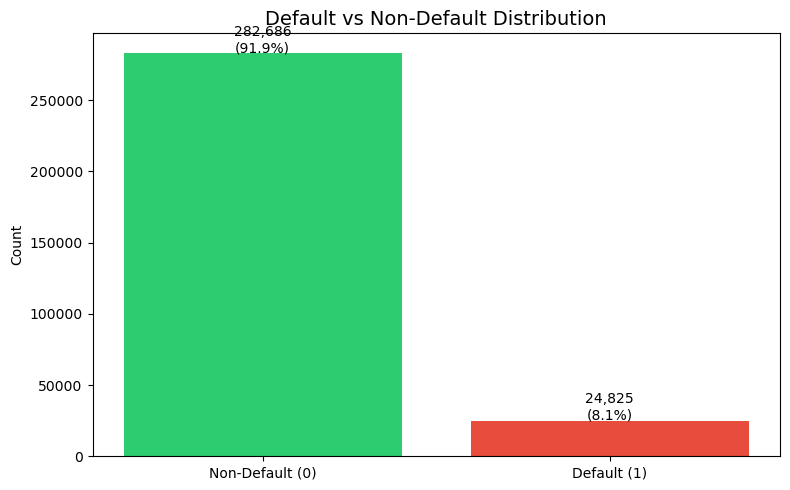

In [18]:
# Default Rate Analysis

total = len(app_data_cleaned)
defaults = app_data_cleaned['TARGET'].sum()
default_rate = (defaults/total)*100

print(f"Total Applications: {total:,}")
print(f"Total Defaults: {defaults:,}")
print(f"Default Rate: {default_rate:.2f}%")

# Plot
plt.figure(figsize=(8,5))
labels = ['Non-Default (0)', 'Default (1)']
values = [total-defaults, defaults]
colors = ['#2ecc71', '#e74c3c']
plt.bar(labels, values, color=colors)
plt.title('Default vs Non-Default Distribution', fontsize=14)
plt.ylabel('Count')
for i, v in enumerate(values):
    plt.text(i, v+1000, f'{v:,}\n({v/total*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('default_distribution.png', dpi=150)
plt.show()

               sum   count  default_rate
CODE_GENDER                             
F            14170  202448      6.999328
M            10655  105059     10.141920
XNA              0       4      0.000000


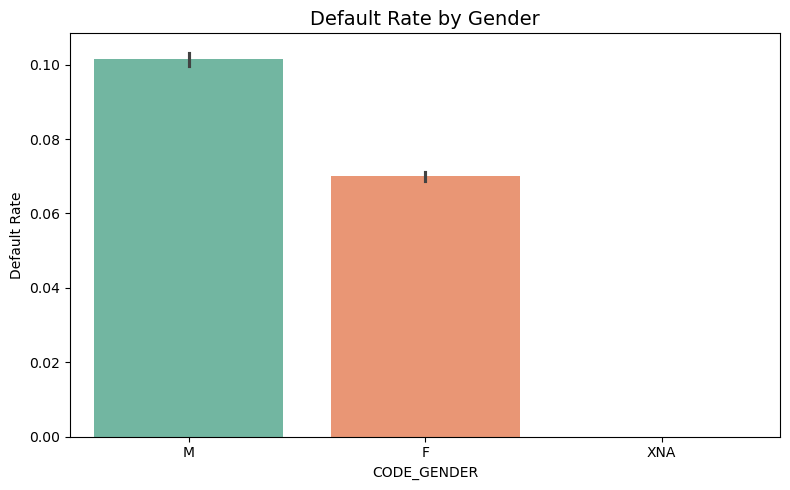

In [19]:
# Gender vs Default

gender_default = app_data_cleaned.groupby('CODE_GENDER')['TARGET'].agg(['sum','count'])
gender_default['default_rate'] = (gender_default['sum']/gender_default['count'])*100
print(gender_default)

plt.figure(figsize=(8,5))
sns.barplot(data=app_data_cleaned, x='CODE_GENDER', y='TARGET', palette='Set2')
plt.title('Default Rate by Gender', fontsize=14)
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('gender_vs_default.png', dpi=150)
plt.show()

Default Rate by Age Group:
AGE_GROUP
20-25    11.741635
26-35    10.585446
36-45     8.237628
46-55     6.848822
55+       5.184410
Name: TARGET, dtype: float64


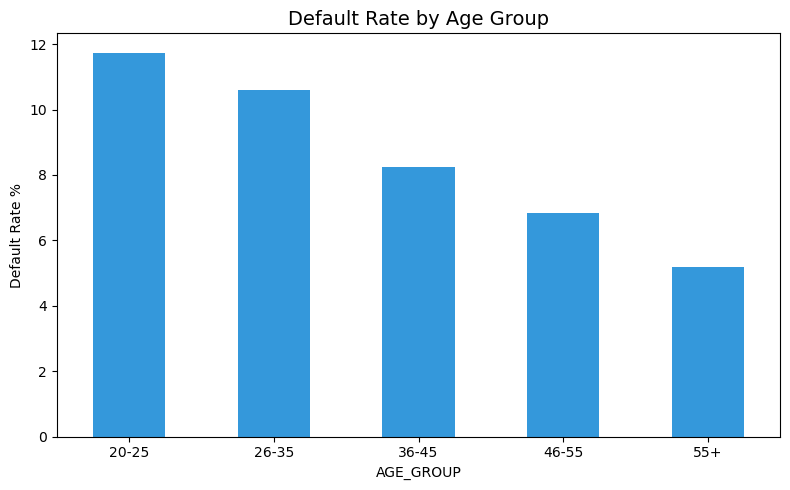

In [20]:
# Age Group vs Default

age_default = app_data_cleaned.groupby('AGE_GROUP')['TARGET'].mean()*100
print("Default Rate by Age Group:")
print(age_default)

plt.figure(figsize=(8,5))
age_default.plot(kind='bar', color='#3498db')
plt.title('Default Rate by Age Group', fontsize=14)
plt.ylabel('Default Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('age_vs_default.png', dpi=150)
plt.show()

Default Rate by Income Type:
NAME_INCOME_TYPE
Maternity leave         40.000000
Unemployed              36.363636
Working                  9.588472
Commercial associate     7.484257
State servant            5.754965
Pensioner                5.386366
Businessman              0.000000
Student                  0.000000
Name: TARGET, dtype: float64


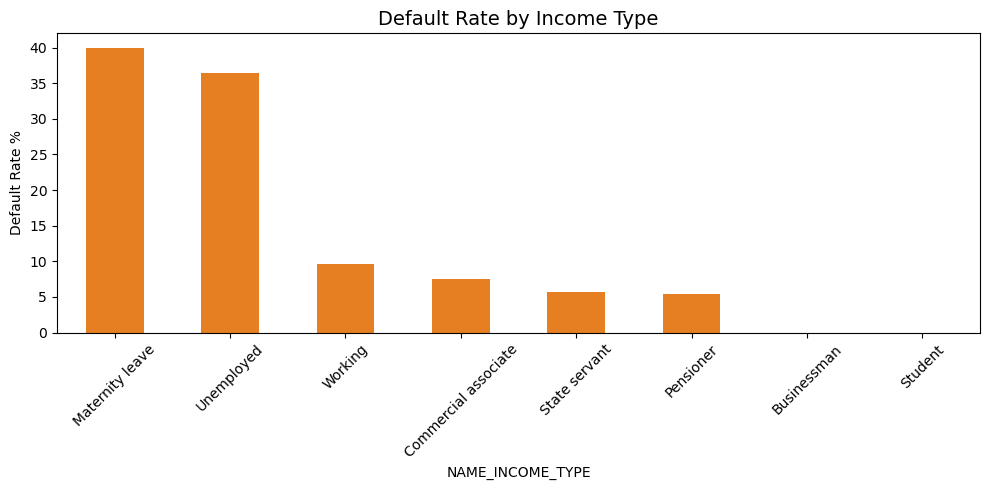

In [21]:
# Income Type vs Default
income_default = app_data_cleaned.groupby('NAME_INCOME_TYPE')['TARGET'].mean()*100
income_default = income_default.sort_values(ascending=False)
print("Default Rate by Income Type:")
print(income_default)

plt.figure(figsize=(10,5))
income_default.plot(kind='bar', color='#e67e22')
plt.title('Default Rate by Income Type', fontsize=14)
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('income_vs_default.png', dpi=150)
plt.show()

Default Rate by Education:
NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64


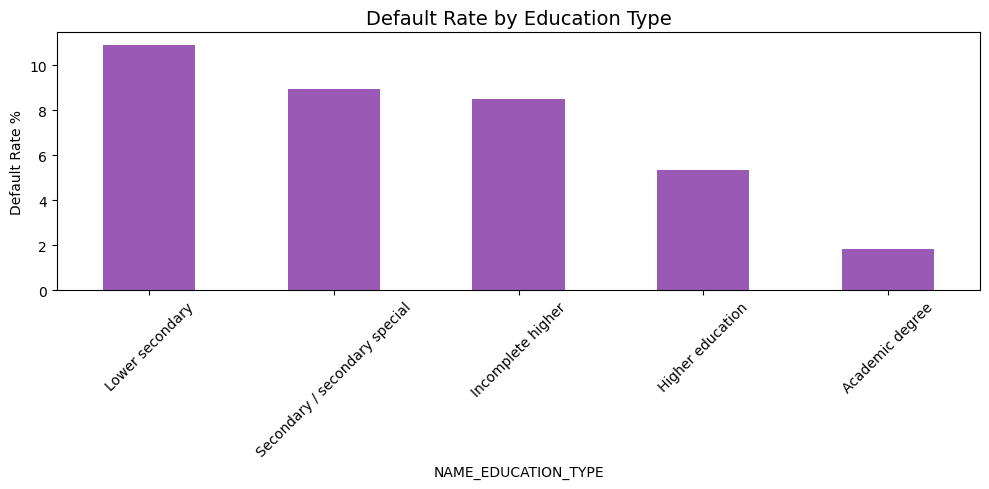

In [22]:
# Education vs Default
edu_default = app_data_cleaned.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()*100
edu_default = edu_default.sort_values(ascending=False)
print("Default Rate by Education:")
print(edu_default)

plt.figure(figsize=(10,5))
edu_default.plot(kind='bar', color='#9b59b6')
plt.title('Default Rate by Education Type', fontsize=14)
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('education_vs_default.png', dpi=150)
plt.show()

Default Rate by Contract Type:
NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64


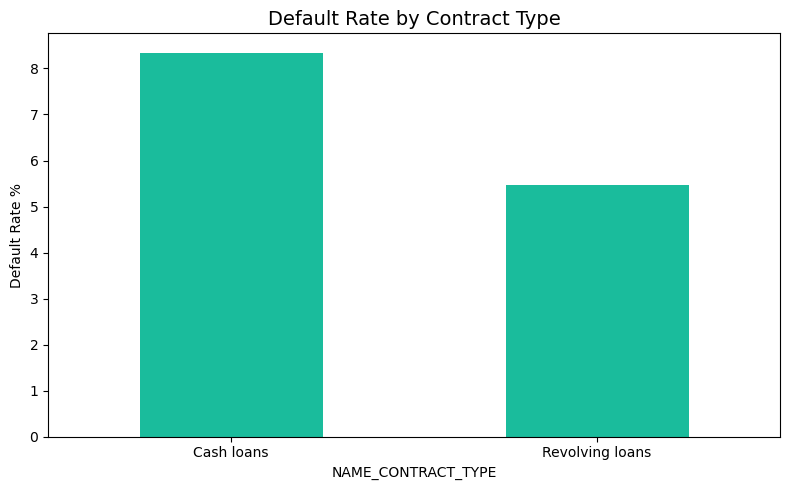

In [23]:
# Contract Type vs Default
contract_default = app_data_cleaned.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean()*100
print("Default Rate by Contract Type:")
print(contract_default)

plt.figure(figsize=(8,5))
contract_default.plot(kind='bar', color='#1abc9c')
plt.title('Default Rate by Contract Type', fontsize=14)
plt.ylabel('Default Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('contract_vs_default.png', dpi=150)
plt.show()

In [24]:
# Merge with Previous Application
prev_status = prev_data.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
prev_status.columns = ['SK_ID_CURR', 'PREV_LOAN_STATUS']

merged_data = app_data_cleaned.merge(prev_status, on='SK_ID_CURR', how='left')
merged_data['PREV_LOAN_STATUS'].fillna('No Previous Loan', inplace=True)

print("Merged data shape:", merged_data.shape)
print("\nPrevious Loan Status vs Default Rate:")
print(merged_data.groupby('PREV_LOAN_STATUS')['TARGET'].mean()*100)

Merged data shape: (307511, 77)

Previous Loan Status vs Default Rate:
PREV_LOAN_STATUS
Approved             7.454968
Canceled             9.572465
No Previous Loan     5.955999
Refused             14.419096
Unused offer         9.665871
Name: TARGET, dtype: float64


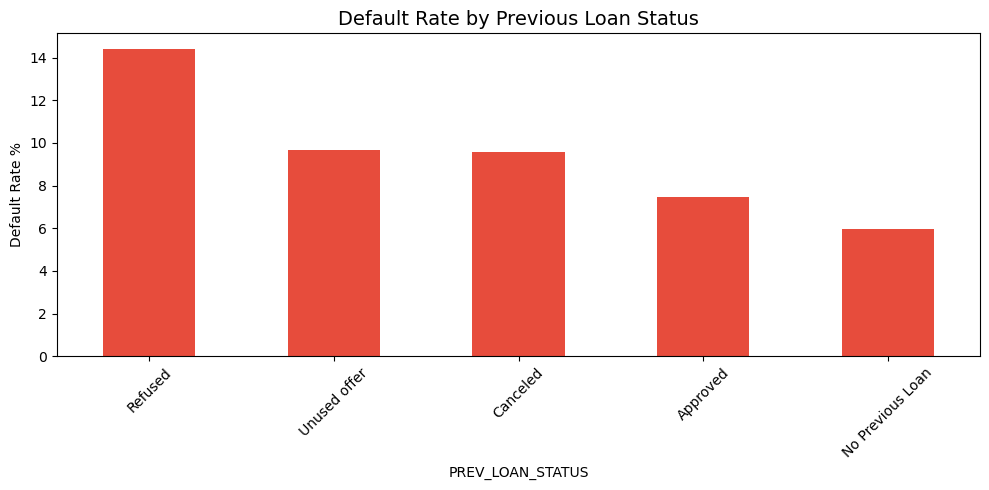

In [25]:
# Previous Loan Status vs Default visualization
prev_default = merged_data.groupby('PREV_LOAN_STATUS')['TARGET'].mean()*100
prev_default = prev_default.sort_values(ascending=False)

plt.figure(figsize=(10,5))
prev_default.plot(kind='bar', color='#e74c3c')
plt.title('Default Rate by Previous Loan Status', fontsize=14)
plt.ylabel('Default Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('prev_loan_vs_default.png', dpi=150)
plt.show()

In [26]:
# GroupBy Analysis
loan_income = app_data_cleaned.groupby('NAME_INCOME_TYPE').agg(
    Total=('TARGET','count'),
    Defaults=('TARGET','sum'),
    Default_Rate=('TARGET','mean')
).round(2).sort_values('Default_Rate', ascending=False)
print(loan_income)

                       Total  Defaults  Default_Rate
NAME_INCOME_TYPE                                    
Maternity leave            5         2          0.40
Unemployed                22         8          0.36
Working               158774     15224          0.10
Commercial associate   71617      5360          0.07
State servant          21703      1249          0.06
Pensioner              55362      2982          0.05
Businessman               10         0          0.00
Student                   18         0          0.00


In [27]:
# Save cleaned data
app_data_cleaned.to_csv('application_data_cleaned.csv', index=False)
merged_data.to_csv('merged_loan_data.csv', index=False)
print("Files saved successfully!")
print(f"Final cleaned dataset: {app_data_cleaned.shape}")
print(f"Final merged dataset: {merged_data.shape}")

Files saved successfully!
Final cleaned dataset: (307511, 76)
Final merged dataset: (307511, 77)
